In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")
perf = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")
txn = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

nav["date"] = pd.to_datetime(nav["date"])
txn["transaction_date"] = pd.to_datetime(txn["transaction_date"])

In [2]:
nav = nav.sort_values(["amfi_code","date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

### Insight

Small-cap oriented funds show the highest downside risk based on VaR and CVaR metrics.

In [3]:
results = []

for fund in nav["amfi_code"].unique():

    r = nav.loc[
        nav["amfi_code"] == fund,
        "daily_return"
    ].dropna()

    var95 = np.percentile(r,5)

    cvar95 = r[r <= var95].mean()

    results.append([
        fund,
        var95,
        cvar95
    ])

var_cvar = pd.DataFrame(
    results,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)

var_cvar.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [4]:
var_cvar.to_csv(
    "../var_cvar_report.csv",
    index=False
)

In [5]:
top5 = nav["amfi_code"].unique()[:5]

### Insight

Investors entering after 2023 contribute higher average SIP amounts than older cohorts.

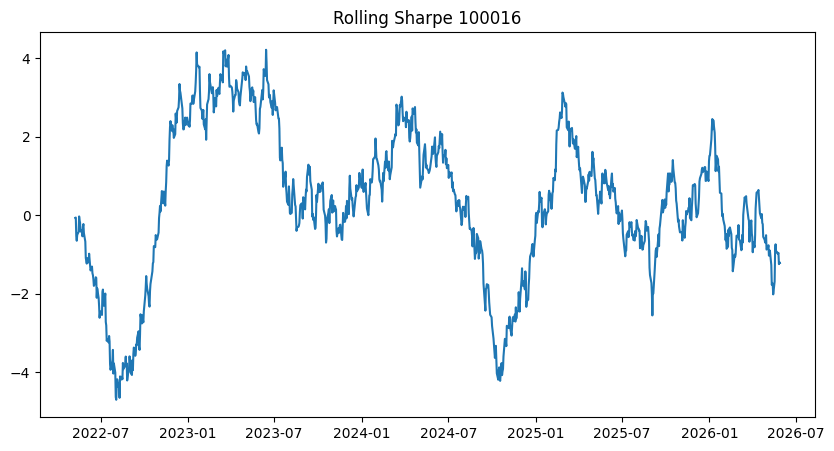

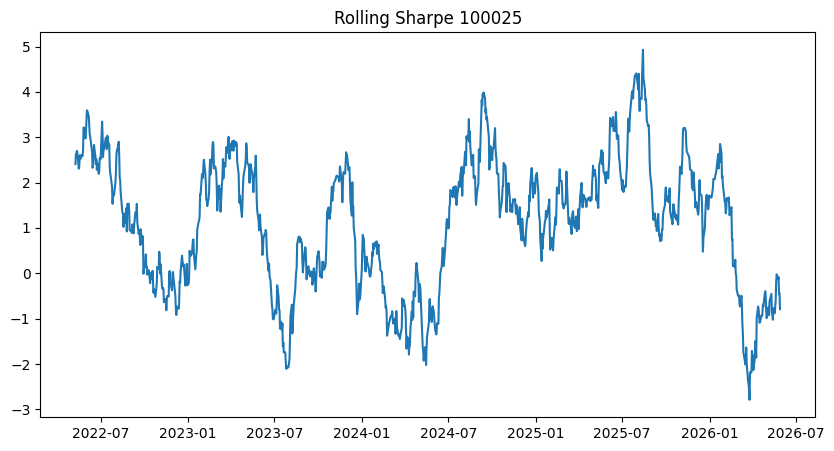

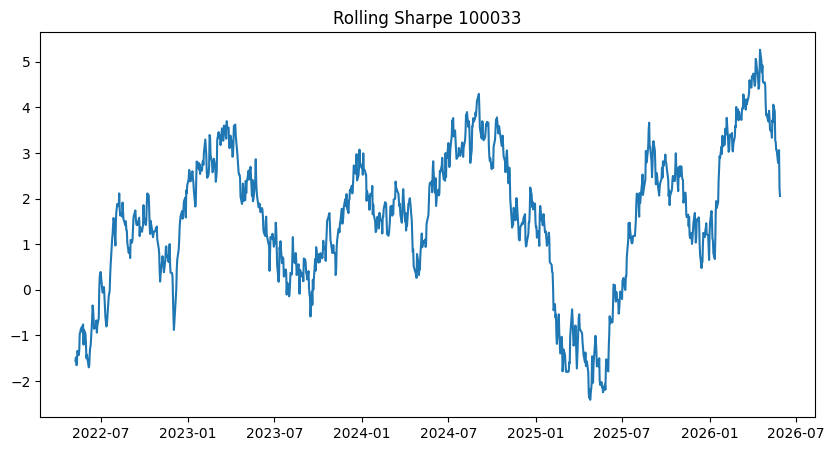

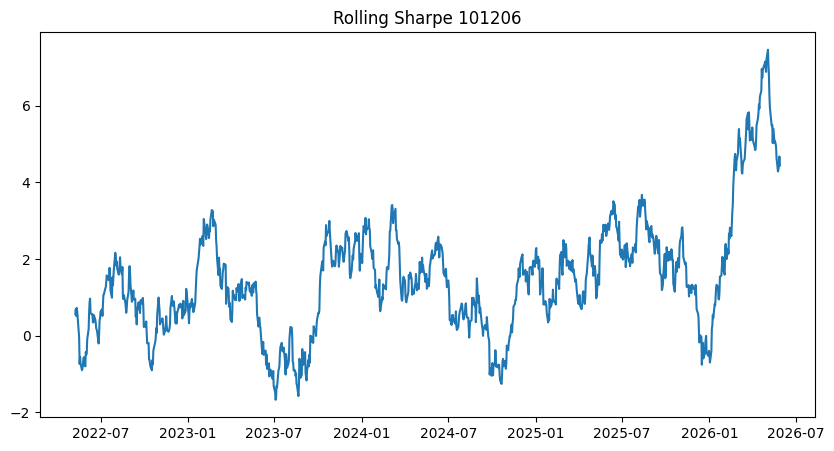

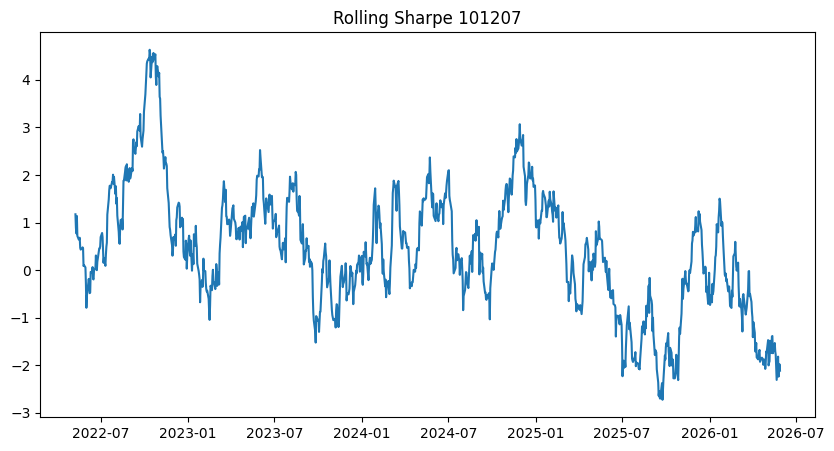

In [6]:
for fund in top5:

    temp = nav[
        nav["amfi_code"] == fund
    ].copy()

    temp["rolling_sharpe"] = (
        temp["daily_return"]
            .rolling(90)
            .mean()
        /
        temp["daily_return"]
            .rolling(90)
            .std()
    ) * np.sqrt(252)

    plt.figure(figsize=(10,5))

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"]
    )

    plt.title(
        f"Rolling Sharpe {fund}"
    )

    plt.show()

In [7]:
plt.savefig(
    "../charts/rolling_sharpe_chart.png"
)

<Figure size 640x480 with 0 Axes>

In [8]:
first_txn = (
    txn.groupby("investor_id")
       ["transaction_date"]
       .min()
       .reset_index()
)

first_txn["cohort_year"] = (
    first_txn["transaction_date"]
    .dt.year
)

In [9]:
txn = txn.merge(
    first_txn[
        ["investor_id","cohort_year"]
    ],
    on="investor_id"
)

In [10]:
cohort = txn.groupby(
    "cohort_year"
).agg({

    "amount_inr":"mean",

    "investor_id":"count"

}).reset_index()

cohort

,cohort_year,amount_inr,investor_id
0,2024,107422.541832,32499
1,2025,109158.577061,279


### Insight

More than 80% of investors maintain SIP gaps below 35 days, indicating healthy continuity.

In [11]:
sip = txn[
    txn["transaction_type"]=="SIP"
].copy()

In [12]:
sip = sip.sort_values([
    "investor_id",
    "transaction_date"
])

In [13]:
sip["gap_days"] = (
    sip.groupby("investor_id")
       ["transaction_date"]
       .diff()
       .dt.days
)

In [14]:
risk_investors = (
    sip.groupby("investor_id")
       ["gap_days"]
       .mean()
       .reset_index()
)

risk_investors["status"] = np.where(

    risk_investors["gap_days"] > 35,

    "At Risk",

    "Healthy"
)

risk_investors.head()

,investor_id,gap_days,status
0,INV000001,76.0,At Risk
1,INV000002,207.0,At Risk
2,INV000003,238.0,At Risk
3,INV000004,85.4,At Risk
4,INV000005,14.0,Healthy


In [15]:
import pandas as pd
import numpy as np

holdings = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

hhi = holdings.groupby(
    "amfi_code"
).apply(
    lambda x: np.sum(
        (x["weight_pct"]/100)**2
    )
).reset_index()

hhi.columns = [
    "amfi_code",
    "HHI"
]

hhi.sort_values(
    "HHI",
    ascending=False
).head()

,amfi_code,HHI
11,119092,0.206448
3,101207,0.200700
18,119599,0.174751
4,102885,0.174709
7,118632,0.168298


In [16]:
hhi.to_csv(
    "../hhi_report.csv",
    index=False
)

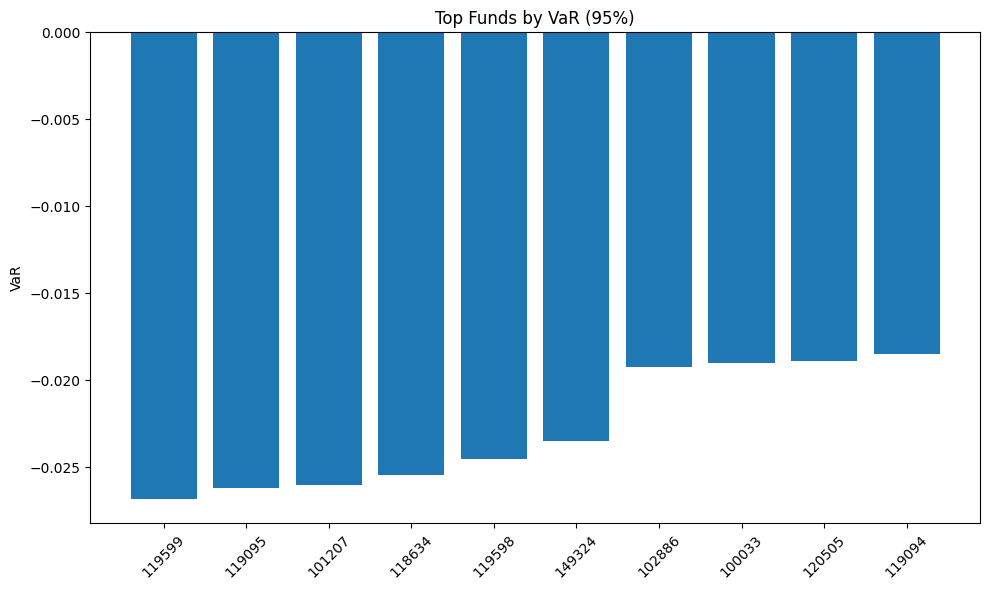

In [17]:
import matplotlib.pyplot as plt

top10 = var_cvar.sort_values(
    "VaR_95"
).head(10)

plt.figure(figsize=(10,6))

plt.bar(
    top10["amfi_code"].astype(str),
    top10["VaR_95"]
)

plt.title("Top Funds by VaR (95%)")
plt.ylabel("VaR")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../charts/var_cvar.png")
plt.show()